In [ ]:
#@title MyDriveのマウントとutilの実行

from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/表のグラフ化_ver2/予防接種/予防接種プログラム/util.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title モジュールのインポート と googleスプレッドシートを読み込むための認証

import pandas as pd
from google.colab import auth
from google.auth import default
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
import gspread
import io
import requests

# 1. 認証
auth.authenticate_user()
creds, _ = default()
if not creds.valid:
    creds.refresh(Request())

# 2. Google Drive APIの設定
drive_service = build('drive', 'v3', credentials=creds)

In [ ]:
#@title 予防接種AかBを選択 { run: "auto" }
vactination_type = 'B' # @param ['A', 'B'] {type:"string"}

print( f"選択された予防接種のタイプ：{vactination_type}")

選択された予防接種のタイプ：A


In [ ]:
#@title googleスプレッドシートを読み込む関数

def load_gsp_and_change_code(target_file):

    # 4. 最初のファイルを選択
    spreadsheet_id = target_file['id']
    # print(f"\n---> 実行対象: {target_file['name']} を読み込みます。")

    # 5. 高速読み込み：CSVエクスポートURLを使ってcsv形式でダウンロードする
    url = f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv'
    headers = {'Authorization': f'Bearer {creds.token}'}
    res = requests.get(url, headers=headers)

    if res.status_code != 200:
        raise Exception(f"データのダウンロードに失敗しました。ステータスコード: {res.status_code}")

    # 6. DataFrame化
    # pd.read_csv()はファイルパスを指定して、その内容を受けとる。
    # res.contentはcsv形式のバイナリデータであるため、io.BytesIO()で疑似ファイルオブジェクトに変換してpd.read_csv()に渡す。
    df = pd.read_csv(io.BytesIO(res.content))

    return df

In [ ]:
#@title 最新の統合googleスプレッドシートの読み込み

# 検索対象のフォルダ内のファイルの取得
folder_name = f'20260331_予防接種{vactination_type}_統合'
files = get_file_names(folder_name)

# リストが空でないか確認してから、最後の要素を取得
if files:
    latest_item = files[-1]
    latest_id = latest_item['id']
    latest_name = latest_item['name']
else:
    print("リストは空です")

print(f'最後に更新された統合ファイル: {latest_name}')
print()

df_latest = load_gsp_and_change_code(latest_item)
print(f"フォルダ内の最新のgoogleスプレッドシートを読み込みました: 長さ：{len(df_latest)}")

display(df_latest)

フォルダー名: 20260331_予防接種A_統合 を探索

フォルダ「20260331_予防接種A_統合」内のスプレッドシート一覧:
  1: 統合_20260403_055328 (ID: 1AP6OD3tm8l5NisvdoNuxo4rSinM9iNJI48G-KFKpB0M)
  2: 統合_20260403_055354 (ID: 17RU2iMEFloGY975wzUQHAwLcmGEa1JSQ6AUV51U6Z68)
  3: 統合_20260403_055706 (ID: 1A5cIPRY68osx9UAtqcnt3KZ4JSngq_Zrvsv0p3nlJJY)
  4: 統合_20260403_064057 (ID: 1W3dss7R0ERoQ3TSglSVn6O80AHAQ4tCsSRrO6dJGq7w)
  5: 統合_20260403_065738 (ID: 105wpulcYTyWgZJHPk0jg7oOB9QiWHFzidPan-lAYdoQ)
  6: 統合_20260403_074036 (ID: 19H4vwBp1qiXq_RfWJZbQ2oeUMpe61HSSf11wkqPPd2w)
  7: 統合_20260403_074053 (ID: 1pcl2gSnFcs3FwSCOQ2yZXtE0hgC37zHNI4Jez8gp4Dg)
  8: 統合_20260403_074110 (ID: 1XwX3gjoAd2wAj_KCQ7yxNDeiL9gRDCOjDEKpIex8RIw)

最後に更新された統合ファイル: 統合_20260403_074110

フォルダ内の最新のgoogleスプレッドシートを読み込みました: 長さ：12


,日付,金額,CD001,CD002,CD003,CD004,CD005,CD006,CD007,CD008,...,CD022,CD023,CD024,CD025,CD026,CD027,CD028,CD029,CD030,CD031
0,2024/07,"1,898,380",64,19,84,1,0,18,14,21,...,0,0,37,64,0,0,0,47,2,0
1,2024/08,"2,069,067",61,23,84,10,0,12,16,27,...,0,0,43,46,0,0,0,35,2,0
2,2024/09,"1,832,375",54,17,72,14,0,10,18,14,...,0,0,31,47,0,0,0,31,1,0
3,2024/10,"2,052,591",59,13,77,6,0,13,31,17,...,0,0,31,64,0,0,0,42,2,0
4,2024/11,"1,440,929",58,19,74,8,0,17,22,7,...,0,0,29,24,0,0,0,21,2,0
5,2024/12,"1,061,673",59,20,77,2,0,15,15,2,...,0,0,23,25,0,0,0,19,1,0
6,2025/01,"1,686,373",54,20,68,0,0,22,24,1,...,0,0,36,32,0,0,0,34,2,0
7,2025/02,"1,558,175",44,19,70,0,0,21,0,14,...,0,0,37,49,0,0,0,25,3,0
8,2025/03,"1,983,272",48,7,64,0,0,23,24,6,...,0,0,41,50,0,0,0,24,3,2
9,2025/04,"1,929,837",59,9,77,0,0,30,13,27,...,0,0,35,62,0,0,0,40,4,0


In [ ]:
import numpy as np

#@title 「日付」以外の「金額」および「CD001」以降の全カラムを整数型（int）に変換

# 1. カンマの除去、および「-」をNaN(None)に置き換え
# regex=True で一括置換。'-' は完全一致で置換するために辞書形式で指定。
df_cleaned = df_latest.replace({',': '', '-': np.nan}, regex=True)

# 2. 「日付」以外のすべての列を整数型に変換
target_cols = df_latest.columns[1:]

# 欠損値(NaN)がある状態で整数化するため、大文字の 'Int64' 型を指定
df_cleaned[target_cols] = df_cleaned[target_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

# 結果の確認
display(df_cleaned.head())

,日付,金額,CD001,CD002,CD003,CD004,CD005,CD006,CD007,CD008,...,CD022,CD023,CD024,CD025,CD026,CD027,CD028,CD029,CD030,CD031
0,2024/07,1898380,64,19,84,1,0,18,14,21,...,0,0,37,64,0,0,0,47,2,0
1,2024/08,2069067,61,23,84,10,0,12,16,27,...,0,0,43,46,0,0,0,35,2,0
2,2024/09,1832375,54,17,72,14,0,10,18,14,...,0,0,31,47,0,0,0,31,1,0
3,2024/10,2052591,59,13,77,6,0,13,31,17,...,0,0,31,64,0,0,0,42,2,0
4,2024/11,1440929,58,19,74,8,0,17,22,7,...,0,0,29,24,0,0,0,21,2,0


In [ ]:
#@title コードをワクチン名に置き換えるためにdict_code_to_itemの作成

if vactination_type == 'A':
    %run '/content/drive/MyDrive/表のグラフ化_ver2/予防接種/予防接種A/20260331_予防接種A_処理データ/vaccination_A_dict_001.ipynb'
else:
    %run '/content/drive/MyDrive/表のグラフ化_ver2/予防接種/予防接種B/20260331_予防接種B_処理データ/vaccination_B_dict_001.ipynb'

# dict_item_to_codeの全ての辞書のキーと値を入れ替える
dict_code_to_item = {v: k for k, v in dict_item_to_code.items()}

In [ ]:
#@title 日本語対応matplotlibのインストール

!pip install japanize-matplotlib --quiet

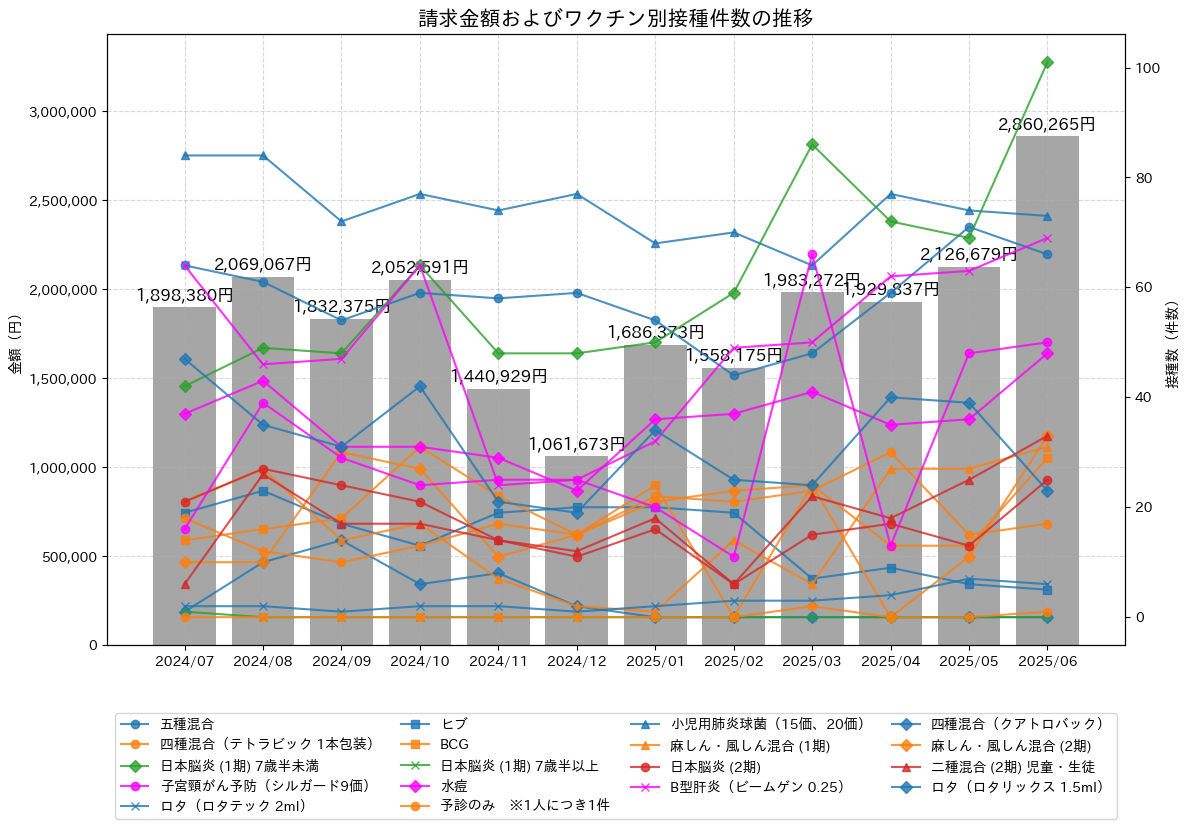

In [ ]:
#@title 描画

import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. 描画準備
fig, ax1 = plt.subplots(figsize=(12, 10)) # 凡例スペースのため高さを少し確保

# 2. 左軸（ax1）: 金額をプロット
ax1.set_ylabel('金額（円）', color='black')

# 1e6表記を消してカンマ区切りにする設定
import matplotlib.ticker as ticker
ax1.get_yaxis().get_major_formatter().set_scientific(False)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

bars = ax1.bar(df_cleaned['日付'], df_cleaned['金額'], color='gray', alpha=0.7)

# Y軸の最大値を自動計算して20%ほど上に空間を作る
current_max = df_cleaned['金額'].max()
ax1.set_ylim(0, current_max * 1.2) # 単位が「円」で長くなるので1.3倍に広げると安心です

# 棒グラフの上部に金額を印字
ax1.bar_label(bars, fmt='{:,.0f}円', padding=3, fontsize=12, color='black', fontweight='bold')

ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# 3. 右軸（ax2）: ワクチン項目をプロット
ax2 = ax1.twinx()
ax2.set_ylabel('接種数（件数）')

# ★ マーカーと色のリスト（5種類）
markers = ['o', 's', '^', 'D', 'x']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'magenta']

cd_cols = df_cleaned.columns[2:]

for i, col in enumerate(cd_cols):
    if df_cleaned[col].any():
        label_name = dict_code_to_item.get(col, col)

        # ★ 5個ごとに色を変える (0-4番目はcolors[0], 5-9番目はcolors[1]...)
        color_idx = (i // 5) % len(colors)
        # ★ マーカーは 0,1,2,3,4 を繰り返す
        marker_idx = i % len(markers)

        ax2.plot(df_cleaned['日付'], df_cleaned[col],
                 alpha=0.8,
                 label=label_name,
                 marker=markers[marker_idx],
                 color=colors[color_idx],
                 markersize=6)

# 4. 凡例の設定
handlers, labels = ax2.get_legend_handles_labels()
num_cols = 4

# 凡例を「左から右、上から下」に並び替えるロジック
reordered_handlers = []
reordered_labels = []
for j in range(num_cols):
    reordered_handlers.extend(handlers[j::num_cols])
    reordered_labels.extend(labels[j::num_cols])

ax2.legend(reordered_handlers, reordered_labels,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=num_cols,
           fontsize=10,
           columnspacing=1.5)

plt.title('請求金額およびワクチン別接種件数の推移', fontsize=15)

fig.tight_layout()
plt.subplots_adjust(bottom=0.35)

plt.show()